In [5]:
"""
Tunisian Dialect Data Collection Pipeline
==========================================
Stage 1: Download, combine, and clean data from HuggingFace sources.

This notebook:
1. Loads datasets from HuggingFace
2. Combines them into one large corpus
3. Applies cleaning transformations
4. Saves processed data for pre-training (Stage 2)
"""

import sys
import importlib
import pandas as pd
import json
from pathlib import Path

# Discover the local scripts directory from the current workspace layout.
# Prefer the repo adjacent to this notebook before any broader fallback search.
scripts_dir = None
priority_candidates = [
    Path(r"c:\\Users\\user\\OneDrive\\Bureau\\New folder\\TunisianDialogSystem\\llm\\cpt\\data\\scripts"),
    Path.cwd() / "data_loader.py",
    Path.cwd() / "TunisianDialogSystem" / "llm" / "cpt" / "data" / "scripts",
    Path.cwd() / "New folder" / "TunisianDialogSystem" / "llm" / "cpt" / "data" / "scripts",
]
for parent in [Path.cwd(), *Path.cwd().parents]:
    priority_candidates.extend([
        parent / "TunisianDialogSystem" / "llm" / "cpt" / "data" / "scripts",
        parent / "New folder" / "TunisianDialogSystem" / "llm" / "cpt" / "data" / "scripts",
    ])

for candidate in dict.fromkeys(priority_candidates):
    if (candidate / "data_loader.py").exists() and (candidate / "data_cleaning.py").exists():
        scripts_dir = candidate
        break

if scripts_dir is None:
    for root in [Path.cwd(), Path.cwd().parent]:
        try:
            for loader_path in root.rglob("data_loader.py"):
                candidate = loader_path.parent
                if (candidate / "data_cleaning.py").exists():
                    scripts_dir = candidate
                    break
            if scripts_dir is not None:
                break
        except Exception:
            continue

if scripts_dir is None:
    raise FileNotFoundError(
        "Could not locate data_loader.py and data_cleaning.py in a local scripts directory."
    )

if str(scripts_dir) not in sys.path:
    sys.path.insert(0, str(scripts_dir))

# Import and force-reload local modules to avoid stale notebook kernel imports
import data_loader
import data_cleaning
importlib.reload(data_loader)
importlib.reload(data_cleaning)

from data_loader import load_all_datasets

print("✅ Imports successful!")
print(f"📁 Using scripts directory: {scripts_dir}")

C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Imports successful!
📁 Using scripts directory: c:\Users\user\OneDrive\Bureau\New folder\TunisianDialogSystem\llm\cpt\data\scripts


In [6]:
# ============================================================================
# STEP 1: LOAD ALL DATASETS
# ============================================================================

# Load all available datasets from HuggingFace
# This may take 5-10 minutes depending on your connection
df_raw = load_all_datasets(include_linagora=True)

print(f"\n📊 Raw combined data shape: {df_raw.shape}")
print(f"   Columns: {list(df_raw.columns)}")
df_raw.head(3)


LOADING TUNISIAN DIALECT DATASETS

✅ Loaded Dialect of Tunisia collection: 291,952 rows
✅ Loaded Tunisian-MSA parallel corpus: 1,000 rows

Loading Linagora Tunisian Derja Dataset configs:
  ✅ Derja_tunsi: 13,037 rows
  ✅ MADAR_TunisianDialect: 12,000 rows
  ✅ QADI_TunisianDialect: 8,879 rows
  ✅ HkayetErwi: 946 rows
  ✅ Sentiment_Derja: 22,890 rows
  ✅ TA_Segmentation: 30,530 rows
  ✅ TSAC: 8,416 rows
  ✅ TuDiCOI: 3,426 rows
  ✅ TunSwitchTunisiaOnly: 380,546 rows
  ✅ TunisianSentimentAnalysis: 23,786 rows
  ✅ Tunisian_Dialectic_English_Derja: 1,220,712 rows
  ✅ Tweet_TN: 39,637 rows
✅ Loaded Linagora Tunisian Derja: 1,764,805 rows total

TOTAL LOADED: 2,057,757 samples


📊 Raw combined data shape: (2057757, 2)
   Columns: ['text', 'source']


,text,source
0,منظمه الدفاع عن المستهلك مكتب بنزرت باش يقدملك...,atakaboudi/Dialect_of_Tunisia-Work_Collection
1,2023 الفلفل الحار 980 الفقوس دينارين و 500 الط...,atakaboudi/Dialect_of_Tunisia-Work_Collection
2,980 الطماطم ب 500 البطاطا بدينار تفاح السبيبه ...,atakaboudi/Dialect_of_Tunisia-Work_Collection


## EDA (Pre-cleaning)

The following cells run quick exploratory data-quality checks on `df_raw` (collected datasets) before the cleaning pipeline is applied. They display distributions, top tokens/characters, duplicates, and a small sample for manual review.


📊 BEFORE VS AFTER CLEANING
Raw samples:      2,057,757

Samples with numbers in raw data:    63,527

Raw text types:
text
arabic    1929420
mixed      123315
french       2677
other        2345
Name: count, dtype: int64

Plot caps (99th percentile) -> words: 370, chars: 2159


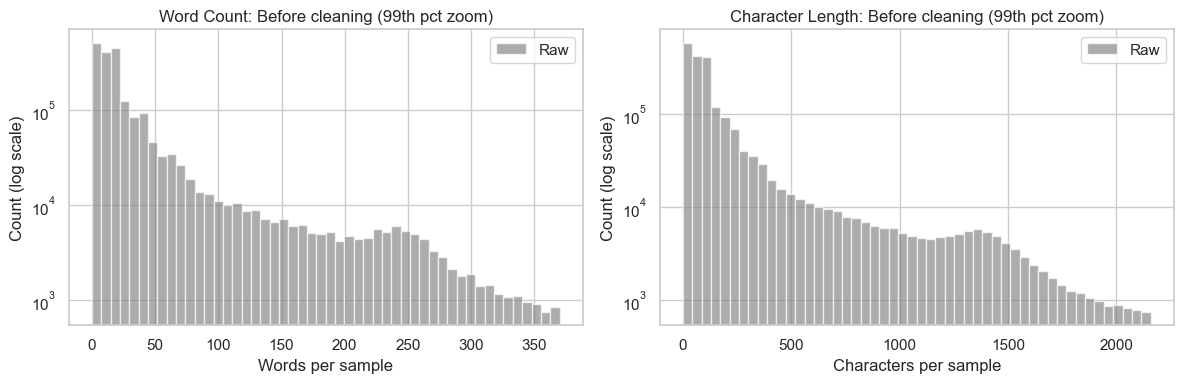


📈 TOP 20 WORDS BEFORE CLEANING:
    1. في                   2,910,946 occurrences
    2. من                   1,562,544 occurrences
    3. ما                   1,320,234 occurrences
    4. على                  1,298,967 occurrences
    5. و                    1,219,397 occurrences
    6. اللي                 834,391 occurrences
    7. باش                  520,417 occurrences
    8. هو                   507,191 occurrences
    9. لا                   454,514 occurrences
   10. كان                  451,023 occurrences
   11. مع                   412,033 occurrences
   12. هي                   333,349 occurrences
   13. هذا                  293,429 occurrences
   14. كل                   265,203 occurrences
   15. ولا                  258,716 occurrences
   16. بش                   256,626 occurrences
   17. يا                   237,059 occurrences
   18. بعد                  232,461 occurrences
   19. أن                   231,039 occurrences
   20. حتى                  223,433 occurrenc

In [13]:
# ============================================================================
# STEP 2: ANALYZE BEFORE CLEANING
# ============================================================================

import matplotlib.pyplot as plt
from data_cleaning import classify_text_type, get_top_words

# Build comparable profiles for raw and cleaned data
raw_profile = df_raw.copy()
raw_profile["text"] = raw_profile["text"].astype(str)
raw_profile["word_count"] = raw_profile["text"].apply(lambda x: len(x.split()))
raw_profile["char_length"] = raw_profile["text"].apply(len)
raw_profile["has_numbers"] = raw_profile["text"].astype(str).str.contains(r'\d', regex=True)


print("\n📊 BEFORE CLEANING")
print("=" * 60)
print(f"Raw samples:      {len(raw_profile):,}")
print(f"\nSamples with numbers in raw data:    {raw_profile['has_numbers'].sum():,}")

# Script composition before/after
raw_types = raw_profile["text"].apply(classify_text_type).value_counts()

print("\nRaw text types:")
print(raw_types)

# Use percentile caps to avoid extreme outliers flattening the histogram scale
wc_cap = max(5, int(raw_profile["word_count"].quantile(0.99)))
cc_cap = max(20, int(raw_profile["char_length"].quantile(0.99)))
print(f"\nPlot caps (99th percentile) -> words: {wc_cap}, chars: {cc_cap}")

raw_wc_plot = raw_profile[raw_profile["word_count"] <= wc_cap]["word_count"]
raw_cc_plot = raw_profile[raw_profile["char_length"] <= cc_cap]["char_length"]

# Visual comparison (zoomed + log count scale)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(raw_wc_plot, bins=50, color="gray", alpha=0.65, label="Raw")
axes[0].set_title("Word Count: Before cleaning (99th pct zoom)")
axes[0].set_xlabel("Words per sample")
axes[0].set_ylabel("Count (log scale)")
axes[0].set_yscale("log")
axes[0].legend()

axes[1].hist(raw_cc_plot, bins=50, color="gray", alpha=0.65, label="Raw")
axes[1].set_title("Character Length: Before cleaning (99th pct zoom)")
axes[1].set_xlabel("Characters per sample")
axes[1].set_ylabel("Count (log scale)")
axes[1].set_yscale("log")
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n📈 TOP 20 WORDS BEFORE CLEANING:")
top_words = get_top_words(raw_profile, text_col="text", top_n=20)
for i, (word, count) in enumerate(top_words, 1):
    print(f"   {i:2d}. {word:20s} {count:,} occurrences")

In [25]:
# ============================================================================
# STEP 2: APPLY CLEANING PIPELINE
# ============================================================================

import inspect
from data_cleaning import full_cleaning_pipeline, print_cleaning_report

print("\nCleaning data...")
print("  - Removing emojis and special characters")
print("  - Normalizing whitespace")
print("  - Removing duplicates and short texts")
print("  - Analyzing text types\n")

# Be robust to stale imports: call with supported signature only
sig = inspect.signature(full_cleaning_pipeline)
if "min_char_length" in sig.parameters:
    df_cleaned = full_cleaning_pipeline(
        df_raw,
        text_col="text",
        min_char_length=50,
        remove_symbols=True,
        analyze=True,
        dominant_word_ratio_threshold=0.5,
    )
else:
    df_cleaned = full_cleaning_pipeline(
        df_raw,
        text_col="text",
        remove_symbols=True,
        excessive_number_ratio=1.0,
        analyze=True,
    )

print_cleaning_report(df_raw, df_cleaned)

# Hard-enforce Arabic-only output dataframe
if "type" in df_cleaned.columns:
    df_cleaned = df_cleaned[df_cleaned["type"] == "arabic"].reset_index(drop=True)

# Remove entries containing specific blocked keyword(s)
blocked_keyword = "الغنوشي"
before_block_filter = len(df_cleaned)
df_cleaned = df_cleaned[~df_cleaned["text"].fillna("").str.contains(blocked_keyword, regex=False)].reset_index(drop=True)
removed_blocked = before_block_filter - len(df_cleaned)
print(f"Removed rows containing '{blocked_keyword}': {removed_blocked:,}")

# Shuffle rows so the final dataset is not kept in source/order-of-loading sequence
df_cleaned = df_cleaned.sample(frac=1).reset_index(drop=True)

print(f"Arabic-only cleaned data shape: {df_cleaned.shape}")
print("✅ Rows shuffled")
df_cleaned.head(3)


Cleaning data...
  - Removing emojis and special characters
  - Normalizing whitespace
  - Removing duplicates and short texts
  - Analyzing text types


DATA CLEANING REPORT
Rows before:        2,057,757
Rows after:         916,221
Rows removed:       1,141,536
Retention rate:     44.5%

Avg char length:    287
Avg word count:     52

Text types:
  arabic: 916,221 (100.0%)

Removed rows containing 'الغنوشي': 11,543
Arabic-only cleaned data shape: (904678, 6)
✅ Rows shuffled


,text,source,char_length,word_count,has_french,type
0,شنو هي خاصية من خصائص المجتمع الملحد النص المع...,linagora/Tunisian_Derja_Dataset::Tunisian_Dial...,248,44,False,arabic
1,احكيلي إيا آش عندك جديد آش أحوال أمك آش ماذا ا...,linagora/Tunisian_Derja_Dataset::Tunisian_Dial...,55,12,False,arabic
2,هاذا حل بأقل خطرخير مالحرقة هاذا حل بأقل بـ أق...,linagora/Tunisian_Derja_Dataset::Tunisian_Dial...,89,18,False,arabic



📊 BEFORE VS AFTER CLEANING
Raw samples:      2,057,757
Cleaned samples:  1,166,874
Removed samples:  890,883
Retention rate:   56.7%

Samples with numbers in raw data:    63,527
Samples with numbers in cleaned data: 0

Raw text types:
text
arabic    1929420
mixed      123315
french       2677
other        2345
Name: count, dtype: int64

Cleaned text types (should be only arabic):
type
arabic    1166874
Name: count, dtype: int64

Plot caps (99th percentile) -> words: 370, chars: 2159


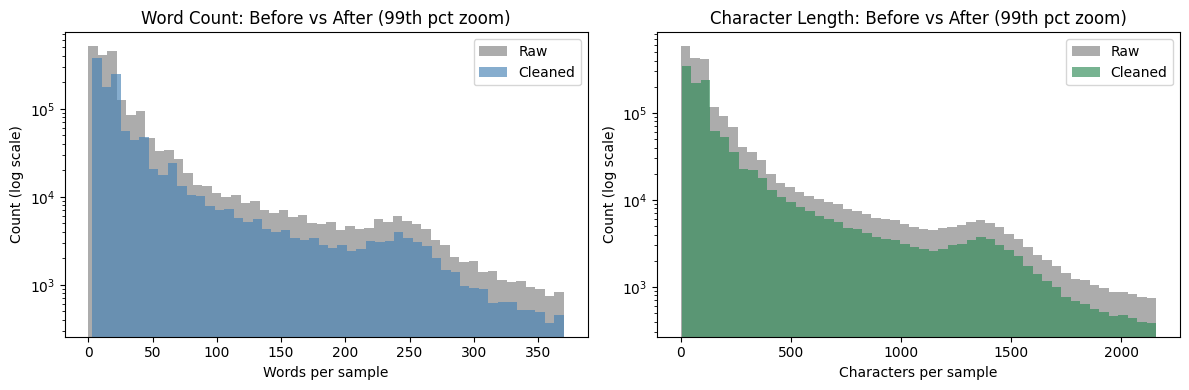


📈 TOP 20 WORDS AFTER CLEANING:
    1. في                   1,414,023 occurrences
    2. من                   791,147 occurrences
    3. على                  660,811 occurrences
    4. ما                   645,396 occurrences
    5. و                    605,099 occurrences
    6. اللي                 435,039 occurrences
    7. باش                  259,429 occurrences
    8. هو                   242,827 occurrences
    9. كان                  232,453 occurrences
   10. مع                   202,097 occurrences
   11. لا                   179,682 occurrences
   12. بش                   163,394 occurrences
   13. هي                   160,019 occurrences
   14. أن                   154,932 occurrences
   15. أو                   142,672 occurrences
   16. هذا                  130,670 occurrences
   17. شنو                  128,392 occurrences
   18. ولا                  118,344 occurrences
   19. برشة                 116,716 occurrences
   20. الجملة               116,617 occurrences


In [21]:
# ============================================================================
# STEP 3: ANALYZE BEFORE VS AFTER CLEANING
# ============================================================================

import matplotlib.pyplot as plt
from data_cleaning import classify_text_type, get_top_words

# Build comparable profiles for raw and cleaned data
raw_profile = df_raw.copy()
raw_profile["text"] = raw_profile["text"].astype(str)
raw_profile["word_count"] = raw_profile["text"].apply(lambda x: len(x.split()))
raw_profile["char_length"] = raw_profile["text"].apply(len)
raw_profile["has_numbers"] = raw_profile["text"].astype(str).str.contains(r'\d', regex=True)

clean_profile = df_cleaned.copy()
clean_profile["has_numbers"] = clean_profile["text"].astype(str).str.contains(r'\d', regex=True)

print("\n📊 BEFORE VS AFTER CLEANING")
print("=" * 60)
print(f"Raw samples:      {len(raw_profile):,}")
print(f"Cleaned samples:  {len(clean_profile):,}")
print(f"Removed samples:  {len(raw_profile) - len(clean_profile):,}")
print(f"Retention rate:   {100 * len(clean_profile) / len(raw_profile):.1f}%")
print(f"\nSamples with numbers in raw data:    {raw_profile['has_numbers'].sum():,}")
print(f"Samples with numbers in cleaned data: {clean_profile['has_numbers'].sum():,}")

# Script composition before/after
raw_types = raw_profile["text"].apply(classify_text_type).value_counts()
clean_types = clean_profile["type"].value_counts() if "type" in clean_profile.columns else pd.Series(dtype=int)

print("\nRaw text types:")
print(raw_types)
print("\nCleaned text types (should be only arabic):")
print(clean_types)

# Use percentile caps to avoid extreme outliers flattening the histogram scale
wc_cap = max(5, int(raw_profile["word_count"].quantile(0.99)))
cc_cap = max(20, int(raw_profile["char_length"].quantile(0.99)))
print(f"\nPlot caps (99th percentile) -> words: {wc_cap}, chars: {cc_cap}")

raw_wc_plot = raw_profile[raw_profile["word_count"] <= wc_cap]["word_count"]
clean_wc_plot = clean_profile[clean_profile["word_count"] <= wc_cap]["word_count"]
raw_cc_plot = raw_profile[raw_profile["char_length"] <= cc_cap]["char_length"]
clean_cc_plot = clean_profile[clean_profile["char_length"] <= cc_cap]["char_length"]

# Visual comparison (zoomed + log count scale)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(raw_wc_plot, bins=50, color="gray", alpha=0.65, label="Raw")
axes[0].hist(clean_wc_plot, bins=50, color="steelblue", alpha=0.65, label="Cleaned")
axes[0].set_title("Word Count: Before vs After (99th pct zoom)")
axes[0].set_xlabel("Words per sample")
axes[0].set_ylabel("Count (log scale)")
axes[0].set_yscale("log")
axes[0].legend()

axes[1].hist(raw_cc_plot, bins=50, color="gray", alpha=0.65, label="Raw")
axes[1].hist(clean_cc_plot, bins=50, color="seagreen", alpha=0.65, label="Cleaned")
axes[1].set_title("Character Length: Before vs After (99th pct zoom)")
axes[1].set_xlabel("Characters per sample")
axes[1].set_ylabel("Count (log scale)")
axes[1].set_yscale("log")
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n📈 TOP 20 WORDS AFTER CLEANING:")
top_words = get_top_words(clean_profile, text_col="text", top_n=20)
for i, (word, count) in enumerate(top_words, 1):
    print(f"   {i:2d}. {word:20s} {count:,} occurrences")

In [ ]:
# ============================================================================
# STEP 4: CALCULATE TOKEN STATISTICS
# ============================================================================

try:
    from transformers import AutoTokenizer
    from data_cleaning import count_tokens
    
    print("\n📊 TOKENIZATION STATISTICS")
    print("Loading tokenizer for token counting...")
    
    # Use a multilingual model compatible with Arabic
    tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")
    
    total_tokens_arabic = count_tokens(clean_profile, tokenizer, text_col="text")
    
    print(f"\n✅ Arabic-only dataset:")
    print(f"   Samples: {len(clean_profile):,}")
    print(f"   Total tokens: {total_tokens_arabic:,}")
    print(f"   Avg tokens/sample: {total_tokens_arabic / len(clean_profile):.0f}")
    
except Exception as e:
    print(f"⚠️  Could not load tokenizer: {e}")
    print("   You can calculate tokens later with your specific tokenizer")

KeyboardInterrupt: 

In [ ]:
# ============================================================================
# STEP 5: SAVE PROCESSED DATA
# ============================================================================

# Create output directory next to the discovered scripts tree.
output_dir = scripts_dir.parent / "processed"
output_dir.mkdir(parents=True, exist_ok=True)

print("\n💾 SAVING PROCESSED DATASETS...")

# Save main dataset (Arabic-only)
output_file_arabic = output_dir / "tunisian_arabic_clean.parquet"
clean_profile.to_parquet(output_file_arabic)
print(f"✅ Saved: {output_file_arabic}")
print(f"   Size: {output_file_arabic.stat().st_size / 1e9:.2f} GB")


# Save metadata
metadata = {
    "source": "Stage 1 - Data Collection",
    "raw_samples": len(df_raw),
    "cleaned_samples": len(df_cleaned),
    "arabic_only_samples": len(df_cleaned),
    "cleaning_date": pd.Timestamp.now().isoformat(),
    "sources": [
        "atakaboudi/Dialect_of_Tunisia-Work_Collection",
        "tunis-ai/tunisian-msa-parallel-corpus",
        "linagora/Tunisian_Derja_Dataset (12 splits)"
    ]
}

metadata_file = output_dir / "metadata.json"
with open(metadata_file, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)
print(f"✅ Saved metadata: {metadata_file}")

print("\n" + "="*60)
print("🎉 STAGE 1: DATA COLLECTION COMPLETE!")


💾 SAVING PROCESSED DATASETS...
✅ Saved: C:\Users\user\OneDrive\Bureau\PFA\tunisian-dialogue-system\llm\data\processed\tunisian_arabic_clean.parquet
   Size: 0.18 GB
✅ Saved metadata: C:\Users\user\OneDrive\Bureau\PFA\tunisian-dialogue-system\llm\data\processed\metadata.json

🎉 STAGE 1: DATA COLLECTION COMPLETE!


In [ ]:
# ============================================================================
# STEP 6: UPLOAD FINAL DATASET TO HUGGINGFACE HUB
# ============================================================================

from upload_to_huggingface import upload_dataset

print("\n☁️  Uploading final cleaned dataset to Hugging Face...")

upload_success = upload_dataset(
    parquet_file=str(output_file_arabic),
    repo_name="tunisian-dialect-corpus",
    username="Syrinesmati",
    description="Cleaned Tunisian dialect corpus",
    make_private=False,
)

if upload_success:
    print("✅ Final dataset upload completed successfully")
else:
    print("⚠️  Final dataset upload did not complete")